<a href="https://colab.research.google.com/github/cz2112/hw/blob/main/Notebooks/Chap13/13_1_Graph_Representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 13.1: Graph representation**

This notebook investigates representing graphs with matrices as illustrated in figure 13.4 from the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
# Routine to draw graph structure
def draw_graph_structure(adjacency_matrix):

  G = nx.Graph()
  n_node = adjacency_matrix.shape[0]
  for i in range(n_node):
    for j in range(i):
      if adjacency_matrix[i,j]:
          G.add_edge(i,j)

  nx.draw(G, nx.spring_layout(G, seed = 0), with_labels=True)
  plt.show()

[[0 1 0 1 0 0 0 0]
 [1 0 1 1 1 0 0 0]
 [0 1 0 0 1 0 0 0]
 [1 1 0 0 1 0 0 0]
 [0 1 1 1 0 1 0 1]
 [0 0 0 0 1 0 1 1]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 1 0 0]]


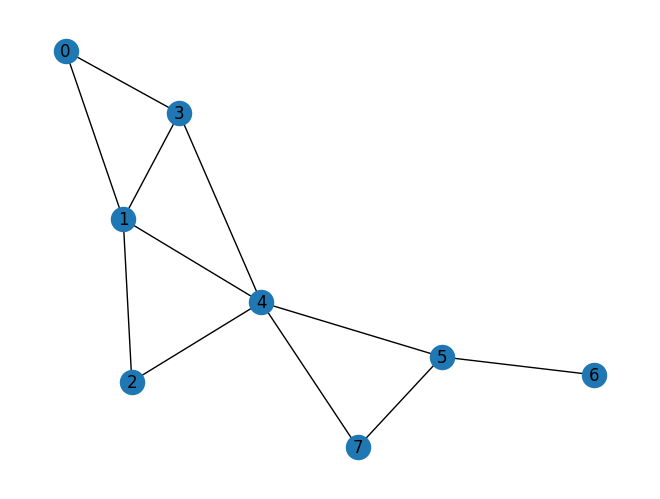

In [3]:
# Define a graph
# Note that the nodes are labelled from 0 rather than 1 as in the book
A = np.array([[0,1,0,1,0,0,0,0],
     [1,0,1,1,1,0,0,0],
     [0,1,0,0,1,0,0,0],
     [1,1,0,0,1,0,0,0],
     [0,1,1,1,0,1,0,1],
     [0,0,0,0,1,0,1,1],
     [0,0,0,0,0,1,0,0],
     [0,0,0,0,1,1,0,0]]);
print(A)
draw_graph_structure(A)

In [4]:
# TODO -- find algorithmically how many walks of length three are between nodes 3 and 7
# We compute A^3 and find the value at row 3, column 7.
A_cubed = np.linalg.matrix_power(A, 3)
walks_3_to_7 = A_cubed[3, 7]

print(f"Number of walks between nodes three and seven = {walks_3_to_7}")

Number of walks between nodes three and seven = 2


In [5]:
# TODO -- find algorithmically what the minimum path distance between nodes 0 and 6 is
# (i.e. what is the first walk length with non-zero count between 0 and 6)

A_k = A.copy()
min_distance = -1
num_nodes = A.shape[0]

# Iterate up to the maximum possible distance (number of nodes - 1)
for k in range(1, num_nodes):
    if A_k[0, 6] > 0:
        min_distance = k
        break
    A_k = A_k @ A # Multiply by A to increment the path length being checked

print(f"Minimum distance = {min_distance}")

# What is the worst case complexity of your method?
# Answer: The worst-case time complexity of this specific matrix-multiplication method is $O(V^4)$,
# where $V$ is the number of vertices. This is because naive matrix multiplication takes $O(V^3)$
# and in the worst case (a long line graph), we might need to multiply the matrix $V-1$ times.
# (Note: standard graph traversal algorithms like Breadth-First Search would solve this in $O(V + E)$ time).

Minimum distance = 4


In [6]:
# Now let's represent node 0 as a vector
x = np.array([[1],[0],[0],[0],[0],[0],[0],[0]]);
print(x)

[[1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [7]:
# TODO: Find algorithmically how many paths of length 3 are there between node 0 and every other node
# Multiply the matrix A^3 by the initial state vector x
paths_from_zero = np.linalg.matrix_power(A, 3) @ x

print(paths_from_zero)

[[2]
 [6]
 [3]
 [5]
 [3]
 [2]
 [0]
 [2]]
